In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

In [3]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


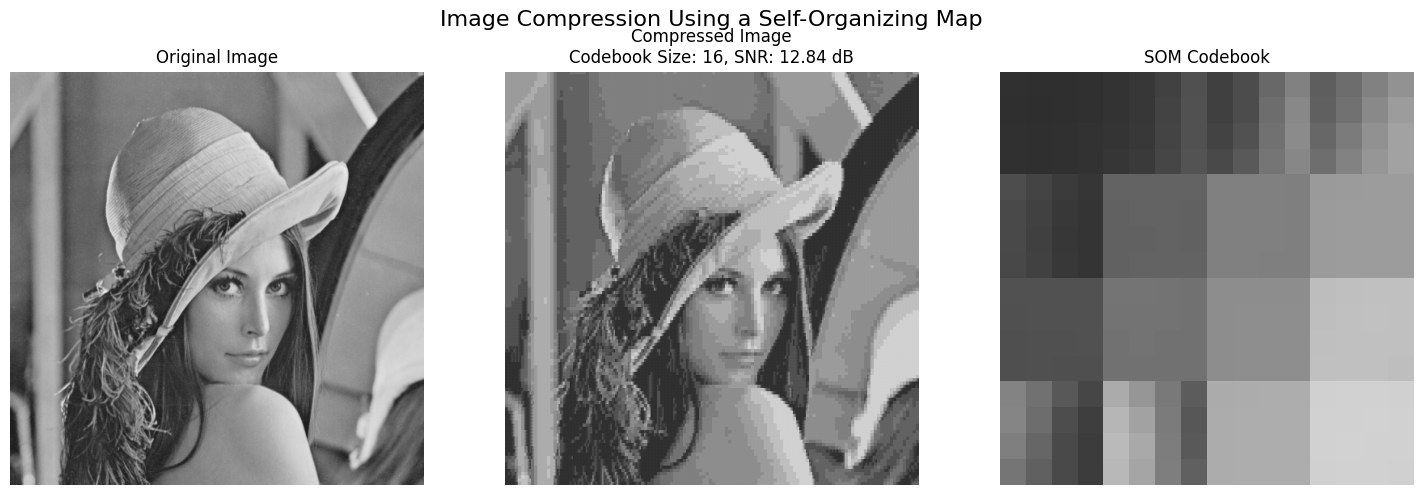

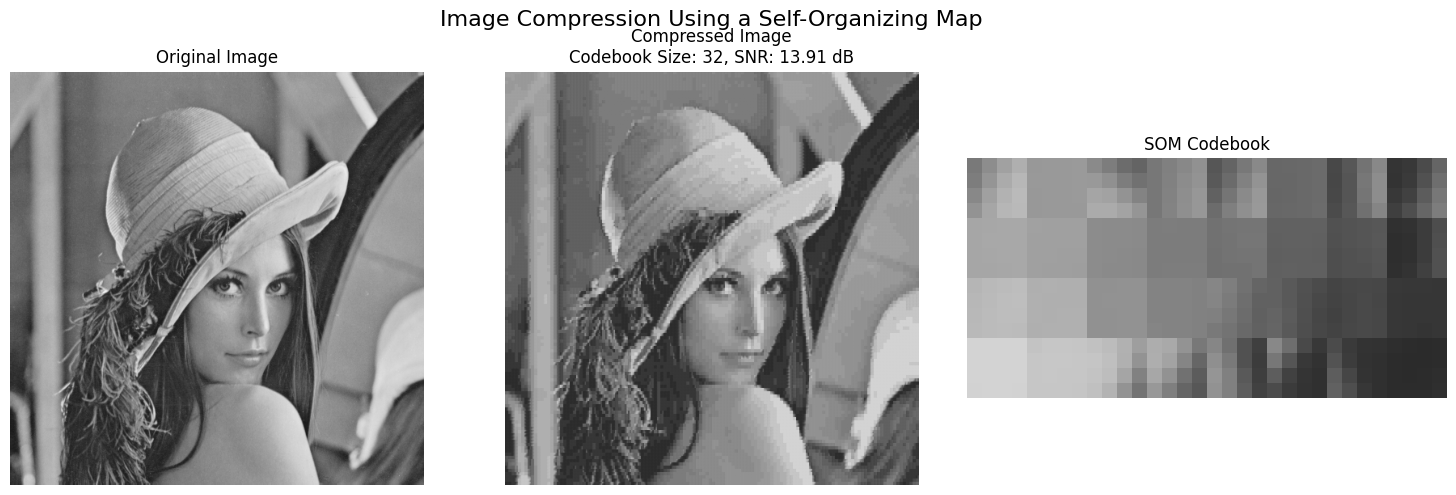

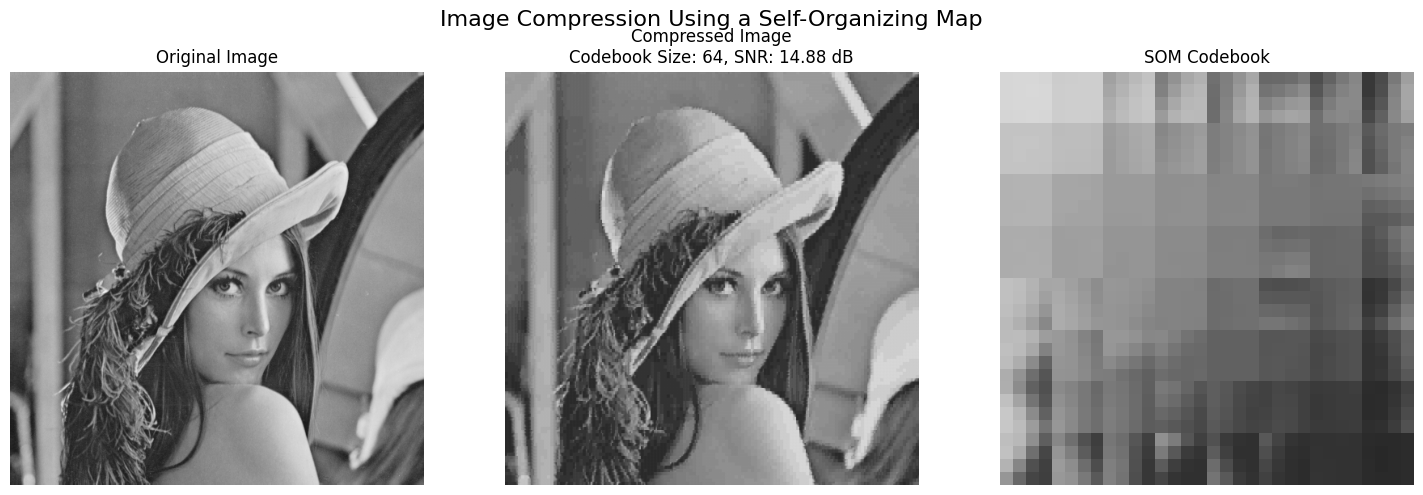

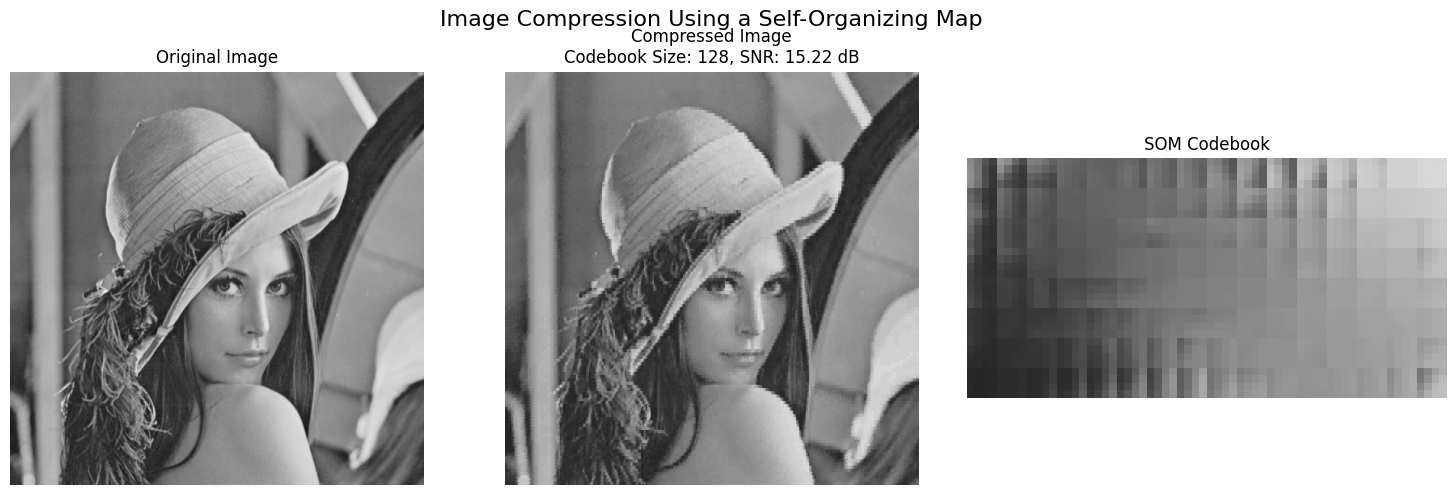

Compression results
-------------------
Codebook size  16: SNR = 12.84 dB
Codebook size  32: SNR = 13.91 dB
Codebook size  64: SNR = 14.88 dB
Codebook size 128: SNR = 15.22 dB

Total runtime: 38.15 seconds


In [5]:
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.vq import vq
from scipy.io import loadmat

# ============================================================
# Configuration
# ============================================================

WORKPATH = Path("/content/drive/MyDrive/DigitalImageProcessing")
DATA_PATH = WORKPATH / "Data" / "lena.mat"

BLOCK_HEIGHT = 4
BLOCK_WIDTH = 4

BITS_PER_CODEVECTOR = range(4, 8)  # Codebook sizes: 16, 32, 64, 128
EPOCHS = 10
INITIAL_LEARNING_RATE = 0.7
RANDOM_SEED = 42


# ============================================================
# Utility functions
# ============================================================

def compute_snr(original, reconstructed):
    """
    Compute signal-to-noise ratio in decibels.
    """
    original = original.astype(np.float64)
    reconstructed = reconstructed.astype(np.float64)

    signal_power = np.var(original)
    noise_power = np.var(original - reconstructed)

    if noise_power == 0:
        return float("inf")

    return 10.0 * np.log10(signal_power / noise_power)


def image_to_vectors(image, block_height, block_width):
    """
    Divide an image into non-overlapping blocks and flatten each block.
    """
    image_height, image_width = image.shape

    vectors = []

    for row in range(0, image_height, block_height):
        for column in range(0, image_width, block_width):
            block = image[
                row:row + block_height,
                column:column + block_width
            ]

            vectors.append(block.reshape(-1))

    return np.asarray(vectors, dtype=np.float64)


def reconstruct_image(
    vector_indices,
    codebook,
    image_shape,
    block_height,
    block_width
):
    """
    Reconstruct an image using the selected codebook vectors.
    """
    image_height, image_width = image_shape

    reconstructed = np.zeros(
        (image_height, image_width),
        dtype=np.float64
    )

    blocks_per_row = image_width // block_width

    for index, codebook_index in enumerate(vector_indices):
        block_row = index // blocks_per_row
        block_column = index % blocks_per_row

        start_row = block_row * block_height
        start_column = block_column * block_width

        block = codebook[codebook_index].reshape(
            block_height,
            block_width
        )

        reconstructed[
            start_row:start_row + block_height,
            start_column:start_column + block_width
        ] = block

    return np.clip(reconstructed, 0, 255).astype(np.uint8)


def create_codebook_image(
    codebook,
    som_rows,
    som_columns,
    block_height,
    block_width
):
    """
    Arrange SOM codebook vectors according to their map locations.
    """
    topology = np.zeros(
        (
            som_rows * block_height,
            som_columns * block_width
        ),
        dtype=np.float64
    )

    for index, weight_vector in enumerate(codebook):
        map_row = index // som_columns
        map_column = index % som_columns

        start_row = map_row * block_height
        start_column = map_column * block_width

        block = weight_vector.reshape(
            block_height,
            block_width
        )

        topology[
            start_row:start_row + block_height,
            start_column:start_column + block_width
        ] = block

    return np.clip(topology, 0, 255).astype(np.uint8)


# ============================================================
# Self-organizing map
# ============================================================

class SOM:
    def __init__(
        self,
        rows,
        columns,
        input_dimension,
        epochs=10,
        learning_rate=0.7,
        sigma=None,
        seed=42
    ):
        self.rows = rows
        self.columns = columns
        self.input_dimension = input_dimension
        self.epochs = epochs
        self.initial_learning_rate = learning_rate

        if sigma is None:
            sigma = max(rows, columns) / 2

        self.initial_sigma = sigma

        self.rng = np.random.default_rng(seed)

        self.weights = self.rng.uniform(
            low=0,
            high=255,
            size=(rows * columns, input_dimension)
        )

        # Locations of all SOM nodes
        self.node_locations = np.array(
            [
                [row, column]
                for row in range(rows)
                for column in range(columns)
            ],
            dtype=np.float64
        )

    def find_bmu(self, input_vector):
        """
        Find the best matching unit.
        """
        distances = np.linalg.norm(
            self.weights - input_vector,
            axis=1
        )

        return np.argmin(distances)

    def update_weights(
        self,
        input_vector,
        bmu_index,
        iteration,
        total_iterations
    ):
        """
        Update the SOM weights using a Gaussian neighborhood.
        """
        progress = iteration / max(total_iterations - 1, 1)

        learning_rate = (
            self.initial_learning_rate * (1.0 - progress)
        )

        sigma = self.initial_sigma * (1.0 - progress)
        sigma = max(sigma, 1e-6)

        bmu_location = self.node_locations[bmu_index]

        map_distances_squared = np.sum(
            (self.node_locations - bmu_location) ** 2,
            axis=1
        )

        neighborhood = np.exp(
            -map_distances_squared / (2.0 * sigma**2)
        )

        influence = learning_rate * neighborhood[:, np.newaxis]

        self.weights += influence * (
            input_vector - self.weights
        )

    def train(self, input_data):
        """
        Train the SOM codebook.
        """
        total_iterations = self.epochs * len(input_data)
        iteration = 0

        for _ in range(self.epochs):
            shuffled_indices = self.rng.permutation(
                len(input_data)
            )

            for index in shuffled_indices:
                input_vector = input_data[index]

                bmu_index = self.find_bmu(input_vector)

                self.update_weights(
                    input_vector,
                    bmu_index,
                    iteration,
                    total_iterations
                )

                iteration += 1

        return self.weights


# ============================================================
# Visualization
# ============================================================

def show_results(
    original,
    reconstructed,
    topology,
    codebook_size,
    snr_value
):
    """
    Display the original image, reconstructed image, and SOM codebook.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(original, cmap="gray", vmin=0, vmax=255)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(
        reconstructed,
        cmap="gray",
        vmin=0,
        vmax=255
    )
    axes[1].set_title(
        f"Compressed Image\n"
        f"Codebook Size: {codebook_size}, "
        f"SNR: {snr_value:.2f} dB"
    )
    axes[1].axis("off")

    axes[2].imshow(
        topology,
        cmap="gray",
        vmin=0,
        vmax=255,
        interpolation="nearest"
    )
    axes[2].set_title("SOM Codebook")
    axes[2].axis("off")

    fig.suptitle(
        "Image Compression Using a Self-Organizing Map",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# Main program
# ============================================================

def main():
    start_time = time.perf_counter()

    # Load the Lena image from the MATLAB file
    mat_data = loadmat(DATA_PATH)

    if "lena" not in mat_data:
        available_keys = [
            key for key in mat_data.keys()
            if not key.startswith("__")
        ]

        raise KeyError(
            f"'lena' was not found in {DATA_PATH}. "
            f"Available variables: {available_keys}"
        )

    original_image = np.asarray(mat_data["lena"])

    # Convert a color image to grayscale when necessary
    if original_image.ndim == 3:
        original_image = cv2.cvtColor(
            original_image.astype(np.uint8),
            cv2.COLOR_RGB2GRAY
        )

    original_image = np.squeeze(original_image)

    if original_image.ndim != 2:
        raise ValueError(
            f"Expected a 2D grayscale image, but received "
            f"shape {original_image.shape}."
        )

    # Convert the image to the uint8 range [0, 255]
    original_image = original_image.astype(np.float64)

    if original_image.max() <= 1.0:
        original_image *= 255.0

    original_image = np.clip(
        original_image,
        0,
        255
    ).astype(np.uint8)

    # Crop dimensions so they are divisible by the block size
    original_height, original_width = original_image.shape

    usable_height = (
        original_height // BLOCK_HEIGHT
    ) * BLOCK_HEIGHT

    usable_width = (
        original_width // BLOCK_WIDTH
    ) * BLOCK_WIDTH

    original_image = original_image[
        :usable_height,
        :usable_width
    ]

    vector_dimension = BLOCK_HEIGHT * BLOCK_WIDTH

    image_vectors = image_to_vectors(
        original_image,
        BLOCK_HEIGHT,
        BLOCK_WIDTH
    )

    results = []

    for bits in BITS_PER_CODEVECTOR:
        codebook_size = 2**bits

        som_rows = int(np.sqrt(codebook_size))

        while codebook_size % som_rows != 0:
            som_rows -= 1

        som_columns = codebook_size // som_rows

        som = SOM(
            rows=som_rows,
            columns=som_columns,
            input_dimension=vector_dimension,
            epochs=EPOCHS,
            learning_rate=INITIAL_LEARNING_RATE,
            sigma=max(som_rows, som_columns) / 2,
            seed=RANDOM_SEED
        )

        codebook = som.train(image_vectors)

        vector_indices, _ = vq(
            image_vectors,
            codebook
        )

        reconstructed_image = reconstruct_image(
            vector_indices,
            codebook,
            original_image.shape,
            BLOCK_HEIGHT,
            BLOCK_WIDTH
        )

        topology_image = create_codebook_image(
            codebook,
            som_rows,
            som_columns,
            BLOCK_HEIGHT,
            BLOCK_WIDTH
        )

        snr_value = compute_snr(
            original_image,
            reconstructed_image
        )

        results.append((codebook_size, snr_value))

        show_results(
            original_image,
            reconstructed_image,
            topology_image,
            codebook_size,
            snr_value
        )

    elapsed_time = time.perf_counter() - start_time

    print("Compression results")
    print("-------------------")

    for codebook_size, snr_value in results:
        print(
            f"Codebook size {codebook_size:3d}: "
            f"SNR = {snr_value:.2f} dB"
        )

    print(f"\nTotal runtime: {elapsed_time:.2f} seconds")


if __name__ == "__main__":
    main()